# Default Prediction Model

## Objective

This part builds a Random Forest model to predict whether a loan may default.

I use Random Forest in two ways:

- Approval-style features: customer and loan information available before or near loan approval
- Monitoring features: approval-style features plus current repayment-warning signals like missed payments and days past due

This keeps the modelling clear. The approval-style version is closer to underwriting. The monitoring version is better for finding risky active loans.


## 1. Import Libraries and Load Data


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent

processed_dir = project_dir / "data" / "processed"
tables_dir = project_dir / "reports" / "tables"
figures_dir = project_dir / "reports" / "figures" / "modeling"
figures_dir.mkdir(parents=True, exist_ok=True)

data_path = processed_dir / "banking_customer_loan_analytics_clean.csv"
loan_df = pd.read_csv(data_path)

loan_df.shape


(11911, 55)

### Data Used

The model uses the clean loan-level dataset. Each row is one loan record, and the target column is `default_flag`.


In [2]:
loan_df[["loan_id", "customer_id", "loan_type", "loan_amount", "repayment_status", "default_flag"]].head()


,loan_id,customer_id,loan_type,loan_amount,repayment_status,default_flag
0,LOAN000001,CUST07874,Education Loan,476245.49,Current,0
1,LOAN000002,CUST05835,Home Loan,2900138.60,Current,0
2,LOAN000003,CUST09330,Home Loan,1647702.57,Current,0
3,LOAN000004,CUST03418,Business Loan,2737180.44,Current,0
4,LOAN000005,CUST07800,Auto Loan,271956.76,Current,0


## 2. Target and Class Balance Check

Before modelling, I check how many loans are default and non-default. I also check this at customer level because one customer can have more than one loan.


In [3]:
loan_target_summary = (
    loan_df["default_flag"]
    .value_counts()
    .rename_axis("default_flag")
    .reset_index(name="loans")
    .sort_values("default_flag")
)
loan_target_summary["loan_pct"] = (loan_target_summary["loans"] / len(loan_df) * 100).round(2)
loan_target_summary["label"] = loan_target_summary["default_flag"].map({0: "Not Default", 1: "Default"})

customer_target = loan_df.groupby("customer_id")["default_flag"].max()
customer_target_summary = (
    customer_target
    .value_counts()
    .rename_axis("default_flag")
    .reset_index(name="customers")
    .sort_values("default_flag")
)
customer_target_summary["customer_pct"] = (customer_target_summary["customers"] / len(customer_target) * 100).round(2)
customer_target_summary["label"] = customer_target_summary["default_flag"].map({0: "No Default Loan", 1: "At Least One Default Loan"})

model_target_summary = pd.DataFrame(
    [
        {
            "level": "Loan",
            "not_default": int(loan_target_summary.loc[loan_target_summary["default_flag"] == 0, "loans"].iloc[0]),
            "default": int(loan_target_summary.loc[loan_target_summary["default_flag"] == 1, "loans"].iloc[0]),
            "total": len(loan_df),
            "default_rate_pct": round(loan_df["default_flag"].mean() * 100, 2),
        },
        {
            "level": "Customer",
            "not_default": int(customer_target_summary.loc[customer_target_summary["default_flag"] == 0, "customers"].iloc[0]),
            "default": int(customer_target_summary.loc[customer_target_summary["default_flag"] == 1, "customers"].iloc[0]),
            "total": len(customer_target),
            "default_rate_pct": round(customer_target.mean() * 100, 2),
        },
    ]
)

model_target_summary.to_csv(tables_dir / "model_default_target_summary.csv", index=False)

print("Loan-level target")
display(loan_target_summary[["label", "loans", "loan_pct"]])

print("Customer-level target")
display(customer_target_summary[["label", "customers", "customer_pct"]])

model_target_summary


Loan-level target


,label,loans,loan_pct
0,Not Default,10433,87.59
1,Default,1478,12.41


Customer-level target


,label,customers,customer_pct
0,No Default Loan,8843,86.03
1,At Least One Default Loan,1436,13.97


,level,not_default,default,total,default_rate_pct
0,Loan,10433,1478,11911,12.41
1,Customer,8843,1436,10279,13.97


### Target Result

At loan level, the model has many more non-default loans than default loans. This is class imbalance.

Because of this, accuracy alone can be misleading. A model can get high accuracy by predicting most loans as not default, but that would not be useful for risk work. I use precision, recall, F1-score, and ROC-AUC along with accuracy.


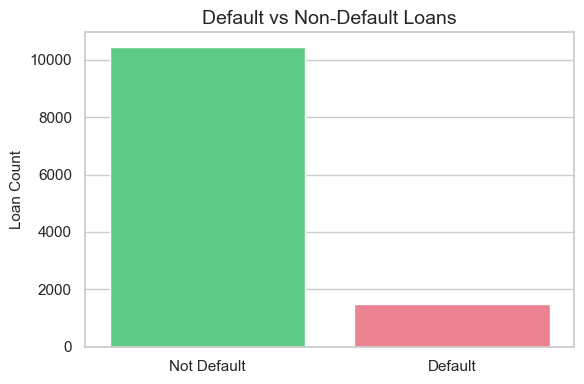

In [4]:
plt.figure(figsize=(6, 4))
sns.barplot(data=loan_target_summary, x="label", y="loans", hue="label", palette=["#4ade80", "#fb7185"], legend=False)
plt.title("Default vs Non-Default Loans")
plt.xlabel("")
plt.ylabel("Loan Count")
plt.tight_layout()
plt.savefig(figures_dir / "target_default_distribution.png", dpi=160)
plt.show()


## 3. Choose Features

I remove fields that would leak the answer into the model.

Removed from model input:

- IDs and names: `loan_id`, `customer_id`, `customer_name`
- final outcome fields: `repayment_status`, `default_flag`
- money outcome field: `expected_loss_amount`
- raw dates: `loan_start_date`, `joined_bank`

I build two feature sets:

- Approval-style features: customer profile, financial position, and loan information
- Monitoring features: approval-style features plus current warning signals


In [5]:
approval_features = [
    "loan_type",
    "loan_amount",
    "loan_term_months",
    "interest_rate",
    "collateral_type",
    "monthly_loan_payment",
    "loan_purpose",
    "credit_score",
    "debt_to_income_ratio",
    "loan_to_value_ratio",
    "age",
    "gender",
    "occupation",
    "employment_status",
    "city",
    "state",
    "banking_relationship",
    "loyalty_classification",
    "annual_income",
    "monthly_income",
    "bank_deposits",
    "checking_balance",
    "savings_balance",
    "credit_card_limit",
    "credit_card_balance",
    "credit_utilization_ratio",
    "business_lending",
    "existing_monthly_debt_payment",
    "total_deposit_balance",
    "deposit_to_income_ratio",
    "customer_tenure_years",
    "loan_to_income_ratio",
    "exposure_after_deposits",
]

monitoring_features = approval_features + [
    "missed_payments_12m",
    "days_past_due",
    "risk_band",
]

target = "default_flag"

print("Approval-style feature count:", len(approval_features))
print("Monitoring feature count:", len(monitoring_features))


Approval-style feature count: 33
Monitoring feature count: 36


## 4. Feature Set Meaning and Leakage Check

This is the important modelling logic.

The target is `default_flag`, so I do not use columns that directly reveal the final outcome, such as `repayment_status`, `default_flag`, or `expected_loss_amount`.

I keep two Random Forest versions because they answer different questions:

- Approval-style: what risk is visible from customer and loan profile?
- Monitoring: which active loans look risky after repayment behavior has started?


In [6]:
feature_set_explanation = pd.DataFrame(
    [
        {
            "feature_set": "Approval-style",
            "main_use": "Loan approval / early risk check",
            "uses_repayment_warning_fields": "No",
            "example_features": "income, credit score, DTI, loan amount, loan type, deposits",
            "important_note": "More realistic before repayment behavior is known",
        },
        {
            "feature_set": "Monitoring",
            "main_use": "Active loan monitoring",
            "uses_repayment_warning_fields": "Yes",
            "example_features": "approval features + missed payments, days past due, risk band",
            "important_note": "Better for finding risky existing loans",
        },
    ]
)

feature_set_explanation.to_csv(tables_dir / "model_feature_set_explanation.csv", index=False)
feature_set_explanation


,feature_set,main_use,uses_repayment_warning_fields,example_features,important_note
0,Approval-style,Loan approval / early risk check,No,"income, credit score, DTI, loan amount, loan t...",More realistic before repayment behavior is known
1,Monitoring,Active loan monitoring,Yes,"approval features + missed payments, days past...",Better for finding risky existing loans


### Leakage Check Result

The approval-style model avoids repayment-warning fields, so it is closer to a before-approval risk check.

The monitoring model includes repayment-warning fields, so it should not be explained as a pure loan-approval model. It is mainly useful after the loan is active.


### Metrics Used

- Precision: when the model says default, how often it is correct
- Recall: out of all actual default loans, how many the model catches
- F1-score: balance between precision and recall
- ROC-AUC: how well the model separates default and non-default loans

For banking risk, recall is important because missing a risky loan can be costly. Precision is also important because too many false alarms waste review effort.


## 5. Helper Functions

These helper functions keep the modelling code simple. They split the data, prepare numeric/categorical columns, train Random Forest, and calculate the same metrics for each feature set.


In [7]:
def build_preprocessor(X):
    numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_features = X.select_dtypes(exclude=["number", "bool"]).columns.tolist()

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ]
    )

    return preprocessor, numeric_features, categorical_features


def calculate_metrics(feature_set_name, y_true, y_pred, y_probability):
    return {
        "feature_set": feature_set_name,
        "model": "Random Forest",
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1_score": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_true, y_probability), 4),
    }


def train_random_forest(feature_set_name, feature_columns):
    X = loan_df[feature_columns].copy()
    y = loan_df[target].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y,
    )

    preprocessor, numeric_features, categorical_features = build_preprocessor(X_train)

    random_forest = RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=1,
    )

    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", random_forest),
        ]
    )

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_probability = pipeline.predict_proba(X_test)[:, 1]

    result = calculate_metrics(feature_set_name, y_test, y_pred, y_probability)
    prediction = {
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
        "y_probability": y_probability,
    }

    return result, pipeline, prediction, numeric_features, categorical_features


## 6. Train Approval-Style Random Forest

This version avoids current repayment-warning fields. It is closer to a loan approval or early-risk model.


In [8]:
approval_result, approval_model, approval_prediction, approval_numeric, approval_categorical = train_random_forest(
    "Approval-style",
    approval_features,
)

pd.DataFrame([approval_result])


,feature_set,model,accuracy,precision,recall,f1_score,roc_auc
0,Approval-style,Random Forest,0.7864,0.3061,0.5676,0.3977,0.7731


### Approval-Style Result

This model has weaker recall because it does not know about recent missed payments or overdue days. That is expected because approval-stage information is less direct than active repayment behavior.


## 7. Train Monitoring Random Forest

This version includes current repayment-warning signals. It is better for active loan monitoring and early risk alerts.


In [9]:
monitoring_result, monitoring_model, monitoring_prediction, monitoring_numeric, monitoring_categorical = train_random_forest(
    "Monitoring",
    monitoring_features,
)

pd.DataFrame([monitoring_result])


,feature_set,model,accuracy,precision,recall,f1_score,roc_auc
0,Monitoring,Random Forest,0.951,0.7258,0.973,0.8314,0.9873


### Monitoring Result

The monitoring model performs better because missed payments, days past due, and risk band are directly related to repayment behavior. This should be explained as an active portfolio-monitoring model.


## 8. Compare Random Forest Feature Sets


In [10]:
metrics_df = pd.DataFrame([approval_result, monitoring_result])
metrics_df = metrics_df.sort_values(["roc_auc", "f1_score"], ascending=False).reset_index(drop=True)
metrics_df.to_csv(tables_dir / "model_performance_metrics.csv", index=False)
metrics_df


,feature_set,model,accuracy,precision,recall,f1_score,roc_auc
0,Monitoring,Random Forest,0.9510,0.7258,0.9730,0.8314,0.9873
1,Approval-style,Random Forest,0.7864,0.3061,0.5676,0.3977,0.7731


### Feature Set Comparison Result

Random Forest performs better with monitoring features because missed payments, days past due, and risk band directly describe current repayment behavior.


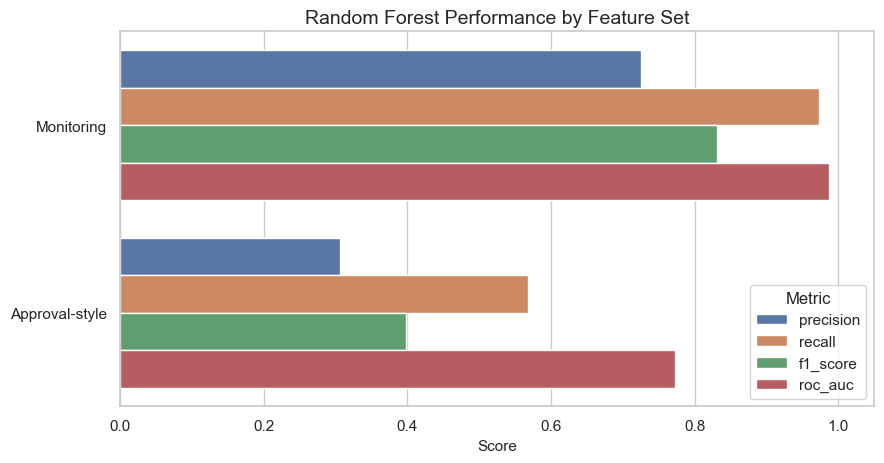

In [11]:
plt.figure(figsize=(9, 4.8))
plot_df = metrics_df.melt(
    id_vars=["feature_set", "model"],
    value_vars=["precision", "recall", "f1_score", "roc_auc"],
    var_name="metric",
    value_name="score",
)
plot_df["model_label"] = plot_df["feature_set"]

sns.barplot(data=plot_df, x="score", y="model_label", hue="metric")
plt.title("Random Forest Performance by Feature Set")
plt.xlabel("Score")
plt.ylabel("")
plt.xlim(0, 1.05)
plt.legend(title="Metric", loc="lower right")
plt.tight_layout()
plt.savefig(figures_dir / "random_forest_feature_set_comparison.png", dpi=160)
plt.show()


## 9. Confusion Matrix for Best Random Forest Version

The best Random Forest version is selected using F1-score and ROC-AUC, not accuracy alone.


In [12]:
best_row = metrics_df.sort_values(["f1_score", "roc_auc"], ascending=False).iloc[0]
best_feature_set = best_row["feature_set"]
best_model_name = "Random Forest"

if best_feature_set == "Approval-style":
    best_model = approval_model
    best_prediction = approval_prediction
else:
    best_model = monitoring_model
    best_prediction = monitoring_prediction

print("Best feature set:", best_feature_set)
print("Best model:", best_model_name)

cm = confusion_matrix(best_prediction["y_test"], best_prediction["y_pred"])
cm_df = pd.DataFrame(cm, index=["Actual Not Default", "Actual Default"], columns=["Predicted Not Default", "Predicted Default"])
cm_df.to_csv(tables_dir / "best_model_confusion_matrix.csv")
cm_df


Best feature set: Monitoring
Best model: Random Forest


,Predicted Not Default,Predicted Default
Actual Not Default,2472,136
Actual Default,10,360


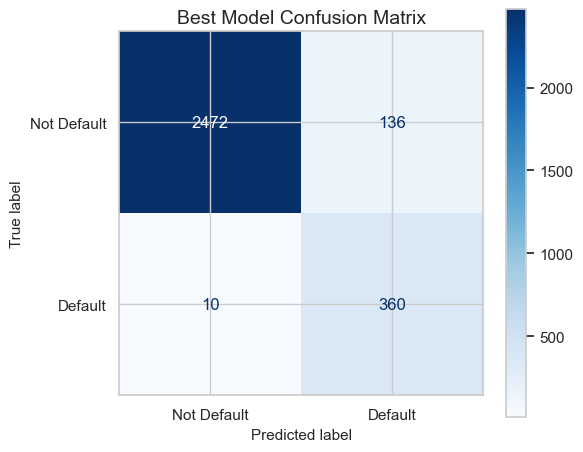

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    best_prediction["y_test"],
    best_prediction["y_pred"],
    display_labels=["Not Default", "Default"],
    cmap="Blues",
    ax=ax,
)
plt.title("Best Model Confusion Matrix")
plt.tight_layout()
plt.savefig(figures_dir / "best_model_confusion_matrix.png", dpi=160)
plt.show()


### Confusion Matrix Result

The confusion matrix shows how many defaults were caught and how many normal loans were incorrectly flagged. For banking risk, recall matters because missing a risky loan can be costly.


## 10. ROC Curve


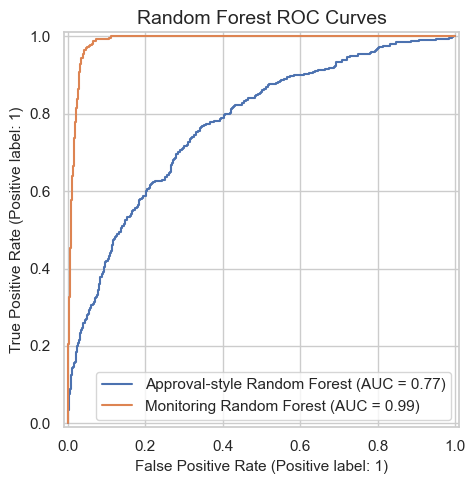

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

for label, prediction in [
    ("Approval-style", approval_prediction),
    ("Monitoring", monitoring_prediction),
]:
    RocCurveDisplay.from_predictions(
        prediction["y_test"],
        prediction["y_probability"],
        name=f"{label} Random Forest",
        ax=ax,
    )

plt.title("Random Forest ROC Curves")
plt.tight_layout()
plt.savefig(figures_dir / "roc_curves.png", dpi=160)
plt.show()


### ROC Result

The ROC curve shows how well the models separate default and non-default loans across different thresholds.


## 11. Random Forest Feature Importance

Feature importance helps explain which fields the Random Forest used most.


In [15]:
rf_model = monitoring_model
preprocessor = rf_model.named_steps["preprocess"]
forest = rf_model.named_steps["model"]

transformed_feature_names = preprocessor.get_feature_names_out()
importance_df = pd.DataFrame(
    {
        "transformed_feature": transformed_feature_names,
        "importance": forest.feature_importances_,
    }
)

def get_original_feature_name(transformed_name):
    if transformed_name.startswith("num__"):
        return transformed_name.replace("num__", "")

    if transformed_name.startswith("cat__"):
        clean_name = transformed_name.replace("cat__", "")
        for column in monitoring_categorical:
            if clean_name.startswith(column + "_"):
                return column

    return transformed_name

importance_df["feature"] = importance_df["transformed_feature"].apply(get_original_feature_name)

feature_importance = (
    importance_df.groupby("feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)
feature_importance["importance_pct"] = (feature_importance["importance"] / feature_importance["importance"].sum() * 100).round(2)
feature_importance.to_csv(tables_dir / "random_forest_feature_importance.csv", index=False)
feature_importance.head(15)


,feature,importance,importance_pct
13,days_past_due,0.384978,38.50
32,risk_band,0.244993,24.50
28,missed_payments_12m,0.144911,14.49
14,debt_to_income_ratio,0.038464,3.85
10,credit_score,0.033126,3.31
24,loan_to_income_ratio,0.017649,1.76
26,loan_type,0.017093,1.71
21,loan_amount,0.016629,1.66
22,loan_purpose,0.013179,1.32
23,loan_term_months,0.009300,0.93


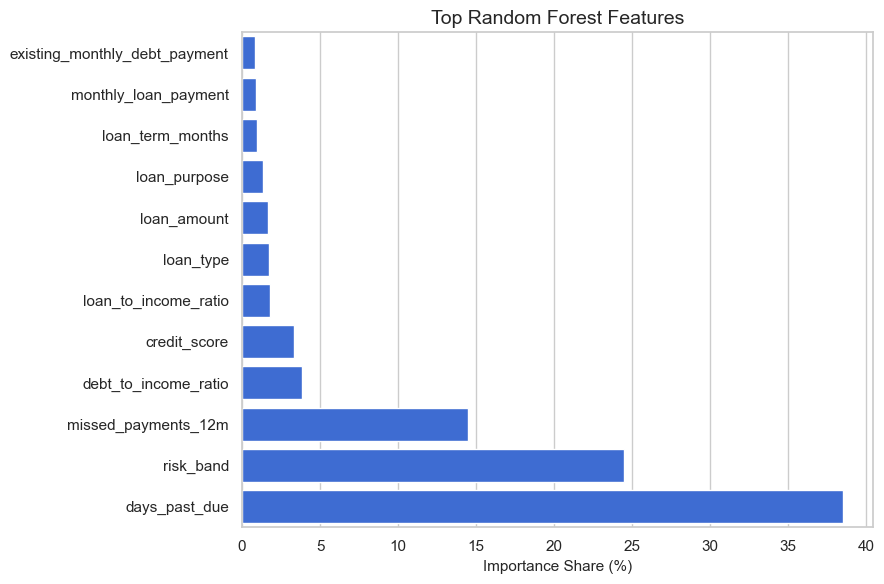

In [16]:
top_features = feature_importance.head(12).sort_values("importance")

plt.figure(figsize=(9, 6))
sns.barplot(data=top_features, x="importance_pct", y="feature", color="#2563eb")
plt.title("Top Random Forest Features")
plt.xlabel("Importance Share (%)")
plt.ylabel("")
plt.tight_layout()
plt.savefig(figures_dir / "random_forest_feature_importance.png", dpi=160)
plt.show()


### Feature Importance Result

The most important features should match the earlier analysis. Strong features are expected to include repayment-warning fields, DTI, credit score, loan amount, and other financial strength indicators.


## 12. High-Risk Loan List

This creates a small table of loans with the highest predicted default probability from the best model.


In [17]:
X_test = best_prediction["X_test"].copy()
y_test = best_prediction["y_test"].copy()
y_probability = best_prediction["y_probability"]
y_pred = best_prediction["y_pred"]

selected_rows = loan_df.loc[X_test.index, [
    "loan_id",
    "customer_id",
    "loan_type",
    "loan_amount",
    "annual_income",
    "credit_score",
    "debt_to_income_ratio",
    "missed_payments_12m",
    "days_past_due",
    "risk_band",
    "repayment_status",
    "default_flag",
]].copy()

selected_rows["predicted_default"] = y_pred
selected_rows["default_probability"] = y_probability
selected_rows["default_probability_pct"] = (selected_rows["default_probability"] * 100).round(2)

high_risk_loans = selected_rows.sort_values("default_probability", ascending=False).head(25)
high_risk_loans.to_csv(tables_dir / "high_risk_loan_predictions.csv", index=False)
high_risk_loans.head(10)


,loan_id,customer_id,loan_type,loan_amount,annual_income,credit_score,debt_to_income_ratio,missed_payments_12m,days_past_due,risk_band,repayment_status,default_flag,predicted_default,default_probability,default_probability_pct
157,LOAN000158,CUST07374,Business Loan,4379741.07,1312404.24,636.0,1.099,9,180,High,Defaulted,1,1,0.962898,96.29
11787,LOAN011788,CUST03137,Business Loan,8231202.90,1180410.21,628.0,1.350,7,180,High,Defaulted,1,1,0.957577,95.76
10779,LOAN010780,CUST00441,Business Loan,3905866.04,808725.46,629.0,1.186,7,173,High,Defaulted,1,1,0.953053,95.31
1242,LOAN001243,CUST07212,Business Loan,4837457.89,1424646.68,565.0,0.932,7,180,High,Defaulted,1,1,0.951547,95.15
2064,LOAN002065,CUST10821,Business Loan,2066386.59,726240.58,623.0,1.313,7,156,High,Defaulted,1,1,0.947917,94.79
2544,LOAN002545,CUST12315,Business Loan,7259058.11,2108684.57,619.0,1.030,9,180,High,Defaulted,1,1,0.945562,94.56
3672,LOAN003673,CUST04118,Business Loan,2753240.50,603380.72,562.0,1.249,7,180,High,Defaulted,1,1,0.945134,94.51
10039,LOAN010040,CUST03989,Business Loan,2224259.00,812848.81,601.0,0.950,7,180,High,Defaulted,1,1,0.942912,94.29
9030,LOAN009031,CUST00662,Business Loan,2637298.27,1229100.88,632.0,0.952,9,180,High,Defaulted,1,1,0.941734,94.17
7878,LOAN007879,CUST04523,Business Loan,5284972.03,1750548.46,593.0,0.960,9,180,High,Defaulted,1,1,0.941219,94.12


### High-Risk List Result

The high-risk list is not a final lending decision. It is a monitoring list that helps identify which active loans should be reviewed first.


## 13. Business Interpretation


In [18]:
test_result = selected_rows.copy()
test_result["probability_group"] = pd.qcut(
    test_result["default_probability"].rank(method="first"),
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"],
)

probability_group_summary = (
    test_result.groupby("probability_group", observed=True)
    .agg(
        loans=("loan_id", "count"),
        actual_defaults=("default_flag", "sum"),
        average_probability=("default_probability", "mean"),
        total_exposure=("loan_amount", "sum"),
    )
    .reset_index()
)
probability_group_summary["actual_default_rate"] = (probability_group_summary["actual_defaults"] / probability_group_summary["loans"] * 100).round(2)
probability_group_summary["average_probability_pct"] = (probability_group_summary["average_probability"] * 100).round(2)
probability_group_summary["total_exposure_crore"] = (probability_group_summary["total_exposure"] / 10_000_000).round(2)
probability_group_summary = probability_group_summary.drop(columns=["average_probability", "total_exposure"])
probability_group_summary.to_csv(tables_dir / "model_probability_group_summary.csv", index=False)
probability_group_summary


,probability_group,loans,actual_defaults,actual_default_rate,average_probability_pct,total_exposure_crore
0,Very Low,596,0,0.00,1.29,28.99
1,Low,595,0,0.00,2.23,92.17
2,Medium,596,0,0.00,7.14,145.60
3,High,595,3,0.50,18.12,171.85
4,Very High,596,367,61.58,74.27,169.92


### Business Result

The probability groups convert model output into a simple risk-ranking view. The bank can use this to review the highest-risk active loans first instead of treating every loan the same.


## 14. Final Summary

I built a Random Forest model to predict `default_flag`.

### Target Meaning

`default_flag` means whether a loan defaulted or not.

- `0`: not default
- `1`: default

In banking terms, default means the borrower failed to repay the loan as agreed.

### Target Counts

Loan-level target:

- not default loans: 10,433
- default loans: 1,478
- total loans: 11,911
- default rate: 12.41%

Customer-level target:

- customers with no default loan: 8,843
- customers with at least one default loan: 1,436
- customers with loans: 10,279
- customer default rate: 13.97%

### Model Setup

Model used:

- Random Forest

Feature sets used:

- Approval-style features
- Monitoring features

Metrics checked:

- accuracy
- precision
- recall
- F1-score
- ROC-AUC

### Model Result

Monitoring Random Forest performed best:

- accuracy: 0.9510
- precision: 0.7258
- recall: 0.9730
- F1-score: 0.8314
- ROC-AUC: 0.9873

Approval-style Random Forest is weaker because it does not use repayment-warning fields:

- accuracy: 0.7864
- precision: 0.3061
- recall: 0.5676
- F1-score: 0.3977
- ROC-AUC: 0.7731

### Why Random Forest Fits This Project

Loan default risk is not controlled by one column only. It depends on combinations like:

- DTI + income
- credit score + loan amount
- missed payments + days past due
- loan type + collateral coverage
- deposits + existing debt

Random Forest handles these combinations better than a single decision tree and also gives feature importance.

### Important Modelling Point

The monitoring version performs better because it includes repayment-warning fields. It should be explained as an active loan-monitoring model.

For loan approval, the approval-style version is more realistic because it avoids current delinquency fields.

### Final Use

The model can help rank loans by default probability. The safest use is as a risk-review support tool, where high-probability loans are checked first by the bank.
